In [1]:
pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("/content/dirty_dataset.csv")
df.head(10)




,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
0,12369,Hasan D.,200.0,35149,2023-05-30,SALES,Man,America,Sylhet,118.4,0,Good value for money.,219.18,NaN,0
1,7361,Grace P.,NaN,77836,2017-02-27,Engineering,FEMALE,America,Chittagong,71kg,True,Product met all expectations.,329.26,NaN,0
2,3446,Eve D.,20.0,35404,2022-01-18,hr,male,BANGLADESH,Chitagong,98.7,False,Very satisfied with the quality.,438.6,NaN,0
3,18416,Diana E.,47.0,107375,2017-04-15,Marketing,Male,U.K.,Khulna,NaN,false,Delivery was fast and packaging great.,238.03,NaN,0
4,13677,Ira W.,64.0,55962,2021-11-02,SALES,F,United Kingdom,Dhaka,83.5,false,Would buy again without hesitation.,9.4,NaN,0
5,458,Frank Y.,38.0,88527,2022-08-16,Mrketing,male,UK,Sylhet,95.8,true,"Excellent product, highly recommend!",213.25,NaN,0
6,16484,John Q.,25.0,109079,2020-09-10,hr,Woman,us,Chitagong,125.2,False,Delivery was fast and packaging great.,19.35,NaN,0
7,12951,Charlie K.,22.0,$91118,2010-01-12,Finace,F,U.K.,Rajshahi,87.9,False,Delivery was fast and packaging great.,419.0,NaN,0
8,13108,Diana V.,43.0,88859,21/07/2016,Marketing,Male,United States,Khulna,73.8,True,good,430.17,NaN,0
9,14925,Alice C.,0.0,46627,2012-01-12,Sales,FEMALE,us,Khulna,110.7,False,Very satisfied with the quality.,429.27,NaN,0


In [4]:
df.tail(10)

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
20290,16444,Charlie I.,60.0,93596,2011-01-24,NaN,Woman,BANGLADESH,Chittagong,116.2,True,Good value for money.,79.97,NaN,0
20291,8369,John W.,24.0,95199,2024-03-28,hr,NaN,U.K.,Khulna,83kg,True,"Excellent product, highly recommend!",336.72,NaN,0
20292,16834,Grace F.,50.0,111758,2019-02-04,Engineering,Female,usa,Chittagong,69.4,False,Would buy again without hesitation.,472.76,NaN,0
20293,12274,Eve F.,50.0,32285,2016-03-21,Mrketing,Female,Bangladesh,NaN,129.4,False,Very satisfied with the quality.,234.92,NaN,0
20294,16440,Charlie W.,37.0,46333,01-27-2016,hr,MALE,U.S.A,Rajshahi,58kg,False,NaN,8.68,NaN,0
20295,19842,Frank N.,27.0,9999999,2010-06-21,engineering,Female,U.K.,Chittagong,93.7,False,Delivery was fast and packaging great.,$199.19,NaN,0
20296,1769,Frank N.,45.0,31616,2021-01-11,hr,F,U.K.,Khulna,NaN,False,Product met all expectations.,223.39,NaN,0
20297,9930,Hasan A.,30.0,70125,2013-07-07,Engineering,Woman,bd,Khulna,116.3,True,Would buy again without hesitation.,68.16,NaN,0
20298,3241,Frank D.,58.0,40120,2022-03-25,SALES,M,UK,Rajshahi,72.0,True,NaN,90.83,NaN,0
20299,13498,Alice X.,NaN,114722,2023-08-12,HR,Man,UK,Khulna,74.0,False,NaN,142.13,NaN,0


In [5]:
df.shape

(20300, 15)

In [6]:
df1=df.copy()

In [7]:
df.dtypes

,0
employee_id,int64
name,object
age,float64
salary,object
join_date,object
department,object
gender,object
country,object
city,object
weight_kg,object


## **Task 01 Missing Values (NaN, Empty Strings)**
Many columns have missing values ​​, which can cause problems with data visualization.

In [8]:
df.isnull().sum()

,0
employee_id,0
name,0
age,621
salary,610
join_date,810
department,857
gender,1632
country,608
city,604
weight_kg,643


In [9]:
df['salary']=pd.to_numeric(df['salary'],errors="coerce")
df['price']=pd.to_numeric(df['price'], errors='coerce')
df['weight_kg']=pd.to_numeric(df['weight_kg'],errors="coerce")



In [10]:
#Mean
df['age']=df['age'].fillna(df['age'].median())
df['salary']=df['salary'].fillna(df['salary'].median())
df['price']=df['price'].fillna(df['price'].median())
df['weight_kg']=df['weight_kg'].fillna(df['weight_kg'].median())

In [11]:
df.isnull().sum()

,0
employee_id,0
name,0
age,0
salary,0
join_date,810
department,857
gender,1632
country,608
city,604
weight_kg,0


In [12]:
#mode
df['department']=df['department'].fillna(df['department'].mode()[0])
df['gender']=df['gender'].fillna(df['gender'].mode()[0])
df['country']=df['country'].fillna(df['country'].mode()[0])
df['city']=df['city'].fillna(df['city'].mode()[0])

In [13]:
df['join_date'] = pd.to_datetime(df['join_date'], format='mixed', dayfirst=True)
df['join_date'] =df['join_date'].ffill()

In [14]:
df['review']=df['review'].fillna('No Review').ffill()

In [15]:
df['is_active']=df['is_active'].fillna(False).bfill()

In [16]:
df.isnull().sum()

,0
employee_id,0
name,0
age,0
salary,0
join_date,0
department,0
gender,0
country,0
city,0
weight_kg,0


# **Solutions**
*   Mean Imputation
*   Median Imputation
*   Mode Imputation
*  Forward Fill
*  Backward Fill












*Task 02 Duplicate Rows**

Duplicate values ​​will be found and removed from all data frames.

In [17]:
df.duplicated().sum()

np.int64(291)

In [18]:
df[df.duplicated()]

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
1302,10364,Frank O.,24.0,112578.0,2010-09-10,HR,M,BD,Dhka,95.8,True,Delivery was fast and packaging great.,22.75,NaN,0
1834,16035,Hasan V.,53.0,-500.0,2017-03-01,Marketing,female,BANGLADESH,Chittagong,48.2,False,Product met all expectations.,385.13,NaN,0
2338,12369,Hasan D.,200.0,35149.0,2023-05-30,SALES,Man,America,Sylhet,118.4,0,Good value for money.,219.18,NaN,0
2469,13108,Diana V.,43.0,88859.0,2016-07-21,Marketing,Male,United States,Khulna,73.8,True,good,430.17,NaN,0
2784,7983,Grace G.,32.0,75294.0,2019-02-01,engineering,Man,U.K.,Khulna,60.2,True,"Excellent product, highly recommend!",245.23,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20110,13509,Charlie S.,34.0,106326.0,2016-06-20,Finace,Man,U.S.A,Slyhet,112.3,False,fine,340.03,NaN,0
20140,2388,Eve A.,35.0,98091.0,2017-04-22,SALES,M,America,Slyhet,90.4,False,Good value for money.,451.34,NaN,0
20154,2689,John O.,46.0,45615.0,2019-12-04,hr,F,usa,Rajshahi,87.1,False,Would buy again without hesitation.,341.28,NaN,0
20173,5188,Charlie J.,46.0,75294.0,2017-04-03,HR,Male,BANGLADESH,Chittagong,73.0,True,bad,419.32,NaN,0


In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.shape

(20009, 15)

### **Solutions**


*   Run df.duplicated().sum() to count duplicates.
*   Preview duplicates: df[df.duplicated()]
*   Remove duplicates: df.drop_duplicates(inplace=True)
*   Verify: compare df.shape before and after.

# **Task 03 Duplicate IDs**
'employee_id' has some duplicate rows that need to be removed

In [22]:
df['employee_id'].duplicated().sum()#count duplicate


np.int64(208)

In [23]:
df[df['employee_id'].duplicated(keep=False)]

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
29,250,Frank U.,56.0,90635.0,2013-05-12,Sales,male,Bangladesh,Dhaka,107.3,0,Would buy again without hesitation.,342.24,NaN,1
40,49,John L.,58.0,50810.0,2024-07-22,hr,FEMALE,U.K.,Dhakka,108.8,False,"Excellent product, highly recommend!",83.46,NaN,0
75,48,Ira E.,0.0,101013.0,2013-08-28,engineering,MALE,BD,Dhakka,87.1,0,Good value for money.,318.78,NaN,0
196,436,Charlie S.,29.0,54295.0,2020-08-27,Mrketing,M,us,Chittagongg,75.9,False,Product met all expectations.,265.25,NaN,0
270,86,Bob U.,36.0,61688.0,2012-11-23,engineering,M,bd,Sylhet,91.7,False,na,167.05,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20016,207,Bob M.,63.0,73657.0,2013-10-08,Mrketing,M,USA,Rajshahi,125.5,False,Very satisfied with the quality.,167.18,NaN,0
20072,435,Charlie U.,31.0,112727.0,2016-04-15,engineering,MALE,U.K.,Rajshahi,119.0,1,Good value for money.,242.44,NaN,0
20104,427,Frank U.,33.0,35686.0,2014-03-21,Mrketing,M,usa,Rajshahi,73.8,True,Good value for money.,396.43,NaN,0
20267,35,Eve L.,55.0,40160.0,2015-12-13,Finance,Male,U.K.,Dhaka,61.0,True,Very satisfied with the quality.,106.40,NaN,0


In [24]:
df.drop_duplicates(subset=['employee_id'],keep='first')

,employee_id,name,age,salary,join_date,department,gender,country,city,weight_kg,is_active,review,price,weight_kg_duplicate,target
0,12369,Hasan D.,200.0,35149.0,2023-05-30,SALES,Man,America,Sylhet,118.4,0,Good value for money.,219.18,NaN,0
1,7361,Grace P.,41.0,77836.0,2017-02-27,Engineering,FEMALE,America,Chittagong,87.1,True,Product met all expectations.,329.26,NaN,0
2,3446,Eve D.,20.0,35404.0,2022-01-18,hr,male,BANGLADESH,Chitagong,98.7,False,Very satisfied with the quality.,438.60,NaN,0
3,18416,Diana E.,47.0,107375.0,2017-04-15,Marketing,Male,U.K.,Khulna,87.1,false,Delivery was fast and packaging great.,238.03,NaN,0
4,13677,Ira W.,64.0,55962.0,2021-11-02,SALES,F,United Kingdom,Dhaka,83.5,false,Would buy again without hesitation.,9.40,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20295,19842,Frank N.,27.0,9999999.0,2010-06-21,engineering,Female,U.K.,Chittagong,93.7,False,Delivery was fast and packaging great.,245.23,NaN,0
20296,1769,Frank N.,45.0,31616.0,2021-01-11,hr,F,U.K.,Khulna,87.1,False,Product met all expectations.,223.39,NaN,0
20297,9930,Hasan A.,30.0,70125.0,2013-07-07,Engineering,Woman,bd,Khulna,116.3,True,Would buy again without hesitation.,68.16,NaN,0
20298,3241,Frank D.,58.0,40120.0,2022-03-25,SALES,M,UK,Rajshahi,72.0,True,No Review,90.83,NaN,0


In [25]:
df['employee_id'].duplicated().sum()

np.int64(208)

In [26]:
df.shape

(20009, 15)

### **Solutions**


* Count: df[&#39;employee_id&#39;].duplicated().sum()
* View: df[df['employee_id'].duplicated(keep=False)]
* Option A: keep first occurrence — df.drop_duplicates(subset=['employee_id'], keep=&#39;first&#39;)
* 16. Verify: assert df['employee_id'].duplicated().sum() == 0

## **Task 04 Wrong Date Formats**

Some formatting of 'join_date' is not correct, so it needs to be fixed. Also, the data needs to be handled.

In [27]:
df['join_date'].dtype

dtype('<M8[ns]')

In [28]:
df['join_date']=pd.to_datetime(
    df['join_date'],
    format=np.fix,
    errors='coerce')

In [29]:
df['join_date'].isna().sum()

np.int64(0)

In [30]:
df['join_date']=df['join_date'].fillna(df['join_date'].median())


In [31]:
df['join_date'].isna().sum()

np.int64(0)

In [32]:
df['join_date']=pd.to_datetime(
    df['join_date'],format='%Y-%m-%d',
    errors='coerce'
)

In [33]:
df['join_date'].dtype

dtype('<M8[ns]')

# **Solutions**


* Check dtype: df['join_date'].dtype — will be object.
*  Convert: pd.to_datetime(df[join_date],format=fix, errors=coerce)
* errors=coerceturns unrecognized formats into NaT.
* Handle NaT values: fill with median date.
* Standardize output: df['join_date']=pd.to_datetime(
    df['join_date'],format='%Y-%m-%d',
    errors='coerce'
)
* Verify dtype: df[&#39;join_date&#39;].dtype — should be datetime64.







## **Task 05 Numeric Stored as String**
All data that was String should be converted to Numeric.

In [34]:
df['salary'].dtype


dtype('float64')

In [35]:
df['salary']=(df['salary']
              .astype(str)
              .str.replace('$','',regex=False).astype(float)
              )

In [36]:
df['weight_kg']=(df['weight_kg']
                 .astype(str)
                 .str.replace('kg','',regex=False).astype(float)
)

In [37]:
df['price']=(df['price']
             .astype(str)
             .str.replace('$','',regex=False).astype(float)
)

In [38]:
df['salary']=pd.to_numeric(
    df['salary'],
    errors='coerce')

In [39]:
df['salary'].dtype

dtype('float64')

### **Solutions**
* Check dtype: df['salary'].dtype — will be object.
* salary: df['salary'].str.replace('$','',regex=False).astype(float)
* weight_kg: df['weight_kg'].str.replace('$','', regex=False).astype(float)
* 26. price: same approach — strip $ then convert to float.
* Handle errors: pd.to_numeric(df['salary'], errors=coerce)
* Verify: df.dtypes — all three columns should be float64.






## **Task 06 Inconsistent Labels**

I need to fix the random values ​​in some columns in the dataset.

In [40]:
df['country'].unique()

array(['America', 'BANGLADESH', 'U.K.', 'United Kingdom', 'UK', 'us',
       'United States', 'Bangladesh', 'usa', 'U.S.A', 'USA', 'bd', 'BD'],
      dtype=object)

In [41]:
df['country'].value_counts()


,count
country,
USA,2126
usa,1527
U.K.,1521
BD,1514
Bangladesh,1509
U.S.A,1504
us,1499
UK,1495
America,1481


In [42]:
#create dect
country_map={
    "USA" :"United States"
    ,"U.S.A":"United States",
    "us": "United States",
    "America" : "United States",
    "usa":"United States",
    "bd":"Bangladesh",
    "BD":"Bangladesh",
    "BANGLADESH":"Bangladesh",
    "UK":"United Kingdom",
    "U.K.":"United Kingdom"

}

In [43]:
df['country']=df['country'].map(country_map).fillna(df['country'])


In [44]:
df['country'].unique()

array(['United States', 'Bangladesh', 'United Kingdom'], dtype=object)

In [45]:
df['gender'].unique()

array(['Man', 'FEMALE', 'male', 'Male', 'F', 'Woman', 'Female', 'MALE',
       'female', 'M'], dtype=object)

In [46]:
gender_map={
    "Man":"MALE",
    "male" :"MALE",
    "Male":"MALE",
     "M":"MALE",
     "F":"FEMALE",
    "Woman":"FEMALE",
    "Female":"FEMALE",
    "female":"FEMALE"

}

In [47]:
df['gender']=df['gender'].map(gender_map).fillna(df['gender'])

In [48]:
df['gender'].unique()

array(['MALE', 'FEMALE'], dtype=object)

In [49]:
df['gender'].value_counts()

,count
gender,
MALE,10903
FEMALE,9106


In [50]:
df['gender'].str.lower()

,gender
0,male
1,female
2,male
3,male
4,female
...,...
20295,female
20296,female
20297,female
20298,male


In [51]:
df['department'].str.lower()

,department
0,sales
1,engineering
2,hr
3,marketing
4,sales
...,...
20295,engineering
20296,hr
20297,engineering
20298,sales


**Solutions**

* Inspect: df[country].value_counts() to see all unique values.
* Build a mapping dictionary for country
* Apply: df[country] = df[country].map(country_map).fillna(df[country])
* df[gender].str.lower() then map to standard values.
* department: df[department].str.strip().str.title() then fix spellings.
* run value_counts() on each column after fixing.












## **Task 07 Spelling Mistakes**
There will be some spelling mistakes that need to be corrected.

In [52]:
df['city'].value_counts()

,count
city,
Khulna,4353
Rajshahi,3284
Sylhet,3227
Dhaka,3124
Chittagong,3115
Slyhet,514
Dhka,488
Rajshai,485
Chitagong,474


In [53]:
df['city'].unique()

array(['Sylhet', 'Chittagong', 'Chitagong', 'Khulna', 'Dhaka', 'Rajshahi',
       'Chittagongg', 'Slyhet', 'Dhakka', 'Rajshai', 'Dhka'], dtype=object)

In [54]:
df['department'].unique()

array(['SALES', 'Engineering', 'hr', 'Marketing', 'Mrketing', 'Finace',
       'Sales', 'engineering', 'Finance', 'HR'], dtype=object)

In [55]:
city_fix={
    'Slyhet':'Sylhet',
    'Chittagongg':'Chittagong',
    'Chitagong':'Chittagong',
    'Dhka':'Dhaka',
    'Dhakka':'Dhaka',
    'Rajshai':'Rajshahi'

}

In [56]:
df['city']=df['city'].replace(city_fix)

In [57]:
df['city'].unique()

array(['Sylhet', 'Chittagong', 'Khulna', 'Dhaka', 'Rajshahi'],
      dtype=object)

In [58]:
department_map={
    'SALES':'Sales',
    'engineering':'Engineering',
    'hr':'HR',
    'Mrketing':'Marketing',
    'Finace':'Finance'


}

In [59]:
df['department']=df['department'].map(department_map).fillna(df['department'])

In [60]:
df['department'].unique()

array(['Sales', 'Engineering', 'HR', 'Marketing', 'Finance'], dtype=object)

In [61]:
df['department'].value_counts()

,count
department,
Sales,4698
HR,3840
Marketing,3834
Engineering,3833
Finance,3804


## **Solutions**

*   df[city&].value_counts() to find all misspelled cities.
* df[city] = df[city].replace(city_fix)
*  Same approach for department:
*   should only show correct city names.





## **Task 08 Outliers**

The dataset needs to be fixed.

In [62]:
df['salary'].describe()

,salary
count,2.000900e+04
mean,2.304288e+05
std,1.235861e+06
min,-5.000000e+02
25%,5.417900e+04
50%,7.529400e+04
75%,9.635400e+04
max,9.999999e+06


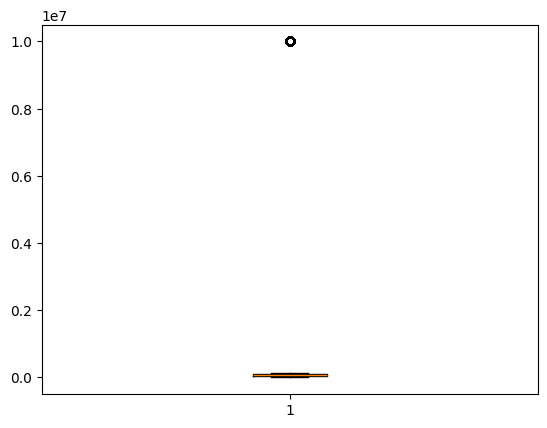

In [63]:
plt.boxplot(df['salary'])
plt.show()

In [64]:
Q1=df['salary'].quantile(.25)
Q1

np.float64(54179.0)

In [65]:
Q3=df['salary'].quantile(.75)
Q3

np.float64(96354.0)

In [66]:
IQR=Q3-Q1
IQR

np.float64(42175.0)

In [67]:
lower=Q1-1.5 * IQR
lower

np.float64(-9083.5)

In [68]:
upper=Q3+1.5 * IQR
upper

np.float64(159616.5)

In [69]:
#Identify
outliers=df[
    (df['salary'] < lower )|
    (df['salary']>upper)
]
len(outliers)

315

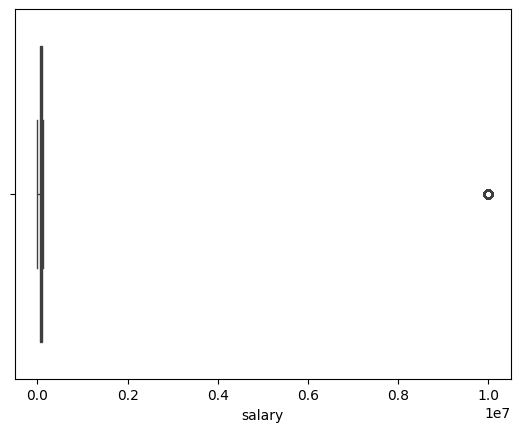

In [70]:
sns.boxplot(x=df['salary'])
plt.show()

In [71]:
df['salary']=df['salary'].clip(
    lower,
    upper
)

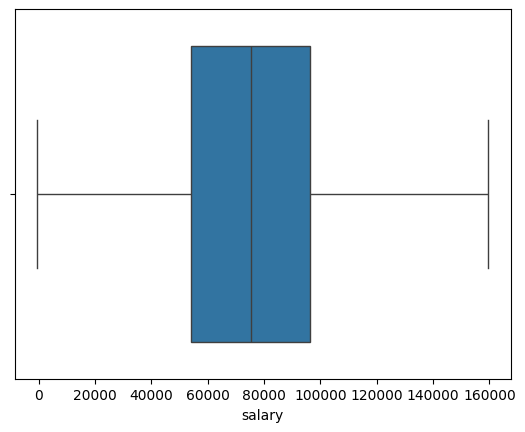

In [72]:
sns.boxplot(x=df['salary'])
plt.show()

In [73]:
df['salary'].describe()

,salary
count,20009.000000
mean,75512.496302
std,27972.891261
min,-500.000000
25%,54179.000000
50%,75294.000000
75%,96354.000000
max,159616.500000


## **Solutions**


* df[salary].describe() to see min, max, mean, std.
* Visualize:plt.boxplot(df[salary])
* Calculate IQR: Q1 = df[salary].quantile(0.25), Q3 = df[salary;].quantile(0.75)
* IQR = Q3 - Q1
* Bounds: lower = Q1 - 1.5*IQR | upper = Q3 + 1.5*IQR
* Identify outliers
*   List item








### **Task 09 Invalid Values**
Find an invalid value, then it will be fixed.

In [74]:
df[
    (df['age'] < 18) |
    (df['age'] > 65)
].shape

(391, 15)

In [75]:
df.loc[df['age'] < 18 ,'age']=np.nan

In [76]:
df.loc[df['age'] > 65,'age']=np.nan

In [77]:
df['age'] = df['age'].clip(18, 65)
df['age'] = df['age'].fillna(df1['age'].median())

In [78]:
df.loc[df['price'] < 0 ]=np.nan

In [79]:
df['age'] = df['age'].clip(18, 65)
df['age'] = df['age'].fillna(df1['age'].median())
assert(
 (df['age'] >= 18).all() &
 (df['age'] <=65).all()
 )

## **Solutions**

* Count invalid ages
* Set invalid ages to NaN: df.loc[df[age] > 18,age] = np.nan
* set invalid ages to NaN: df.loc[df[age] < 165,age] = np.nan
* Fill NaN with median: df[age].fillna(df[age].median(), inplace=True)
* Do the same for price: df.loc[df[price] < 0,price] = np.nan then fill.
* Verify: assert (df[age] >= 18).all() and (df[age] <= 65).all()






# **Task 10 Noisy Text (Reviews)**

You have to make a noisy list and then fill it with no reviews.

In [80]:
df['review'].value_counts()

,count
review,
Delivery was fast and packaging great.,2743
Good value for money.,2722
Product met all expectations.,2695
"Excellent product, highly recommend!",2687
Would buy again without hesitation.,2674
Very satisfied with the quality.,2664
No Review,1419
ok,246
...,235


In [81]:
df['review'].unique()

array(['Good value for money.', 'Product met all expectations.',
       'Very satisfied with the quality.',
       'Delivery was fast and packaging great.',
       'Would buy again without hesitation.',
       'Excellent product, highly recommend!', 'good', 'na', nan, '...',
       'ok ok', 'bad', 'No Review', 'ok', '.', 'fine', 'not bad'],
      dtype=object)

In [82]:
noisy_list=['Good value for money.', 'Product met all expectations.',
       'Very satisfied with the quality.',
       'Delivery was fast and packaging great.',
       'Would buy again without hesitation.',
       'Excellent product, highly recommend!', 'good', 'na', 'nan', '...',
       'ok ok', 'bad', 'No Review', 'ok', '.', 'fine', 'not bad']

In [83]:
df['review']=df['review'].replace(noisy_list,np.nan)

/tmp/ipykernel_3234/2081253722.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['review']=df['review'].replace(noisy_list,np.nan)


In [84]:
df['review'].replace('',np.nan,inplace=True)

/tmp/ipykernel_3234/1502396936.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].replace('',np.nan,inplace=True)


In [85]:
df['review'].fillna("No Review",inplace=True)

/tmp/ipykernel_3234/3557927047.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].fillna("No Review",inplace=True)
/tmp/ipykernel_3234/3557927047.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No Review' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['review'].fillna("No Review",inplace=True)


In [86]:
df['review'].str.split().str.len().value_counts()

,count
review,
2,20009


# **Solutions**

* Inspect: df[review;].value_counts() to identify noisy values.
* Define noisy list: noisy
* Replace noisy values: df[review] = df[review].replace(noisy, np.nan)
*  Also replace empty strings: df[review].replace('', np.nan, inplace=True)
* Fill NaN reviews with No Review
*  Verify: df[review].str.split().str.len().value_counts() — check word count distribution.






### **Task 11 Boolean as String**
String data needs to be converted to Boolean data.

In [87]:
df['is_active'].unique()

array(['0', 'True', 'False', 'false', 'true', 'TRUE', False, nan, '1',
       'FALSE'], dtype=object)

In [88]:
true_vals=['0', 'True', 'False', 'false', 'true', 'TRUE', False, 'nan', '1',
       'FALSE']

In [89]:
df['is_active']=df['is_active'].isin(true_vals)

In [90]:
df['is_active'].dtype

dtype('bool')

In [91]:
df['is_active'].value_counts()

,count
is_active,
True,19613
False,396


# **Solutions**
* Inspect: df[is_active].unique() to see all unique values.
* 63. Define truthy set: true_vals
* Convert: df[is_active] = df[is_active].isin(true_vals)
* df[is_active].dtype — should be bool.
* Check distribution



# **Task 12 Data Type Issues**
Date type needs to be fixed.

In [92]:
df.dtypes

,0
employee_id,float64
name,object
age,float64
salary,float64
join_date,datetime64[ns]
department,object
gender,object
country,object
city,object
weight_kg,float64


In [93]:
expected={
    "employee_id":'int',
    'name':'object',
    'age':'int',
    'salary':'int',
    'join_date':'datetime64[ns]',
    'department':'object',
    'gender':'object',
    'country':'object',
    'city':'object',
    'weight_kg':'float64',
    'is_active':'bool',
    'review':'object',
    'price':'float64',
    'weight_kg_duplicate':'float64',
    'target':'float64'

}

In [94]:
df['age']=df['age'].astype(int)

In [95]:
df['join_date']=pd.to_datetime(df['join_date'])
df['join_date']

,join_date
0,2023-05-30
1,2017-02-27
2,2022-01-18
3,2017-04-15
4,2021-11-02
...,...
20295,2010-06-21
20296,2021-01-11
20297,2013-07-07
20298,2022-03-25


In [96]:
df['is_active']=df['is_active'].astype(bool)
df['is_active']

,is_active
0,True
1,True
2,True
3,True
4,True
...,...
20295,True
20296,True
20297,True
20298,True


In [97]:
df.dtypes

,0
employee_id,float64
name,object
age,int64
salary,float64
join_date,datetime64[ns]
department,object
gender,object
country,object
city,object
weight_kg,float64


# **Solutions**

* Inspect: df.dtypes to see all current data types.
* Define expected types: expected
* Cast columns: df[age] = df[age].astype(float)
* join_date: df[join_date] = pd.to_datetime(df[join_date])
* is_active: df[is_active] = df[is_active;].astype(bool)
* all columns should show correct types





# **Task 13 Range Violations**
You need to set a range and check its validation.

In [98]:
range={
    'age':'(18,65)',
    'price':'(0,10000)',
    'salary':'(15000,500000)'
}

In [99]:
df[
    (df['age'] < 18) |
    (df['age'] > 65)
].shape

(0, 15)

In [100]:
df['age'].clip(18,65)

,age
0,41
1,41
2,20
3,47
4,64
...,...
20295,27
20296,45
20297,30
20298,58


In [101]:
df[
    (df['price'] < 0) |
    (df['price'] > 10000)
].shape

(0, 15)

In [102]:
df['price'].clip(0,10000)

,price
0,219.18
1,329.26
2,438.60
3,238.03
4,9.40
...,...
20295,245.23
20296,223.39
20297,68.16
20298,90.83


In [103]:
df[
    (df['salary'] < 15000) |
    (df['salary'] > 500000)
].shape

(256, 15)

In [104]:
df['salary'].clip(15000,500000)

,salary
0,35149.0
1,77836.0
2,35404.0
3,107375.0
4,55962.0
...,...
20295,159616.5
20296,31616.0
20297,70125.0
20298,40120.0


In [105]:
(df['age'] >= 18).all() & (df['age'] <= 65).all()


np.True_

# **Solutions**

* Define valid ranges: ranges = {age&: (18,65),price: (0, 10000),salary (15000, 500000)}
* Count violations:df[(df['age'] < 18) |(df['age'] > 65)].shape
* clip:df['age'].clip(18,65)
* Apply same logic for price and salary.
* Verify:(df['age'] >= 18).all() & (df['age'] <= 65).all()






# **Task 14 Class Imbalance**
Imbalanced data needs to be fixed.

In [106]:
df['target'].value_counts()
df['target'].value_counts(normalize=True)*100

,proportion
target,
0.0,95.003314
1.0,4.996686


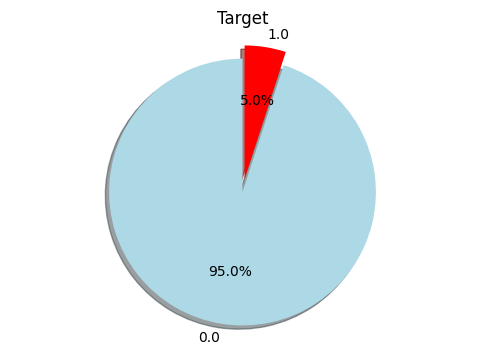

In [107]:
target=df['target'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(target,
        labels=target.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightblue','red'],
        explode=(0,0.1),shadow=True

        )
plt.title('Target')
plt.axis('equal')
plt.show()

In [108]:
from imblearn.over_sampling import RandomOverSampler
df_cleaned = df.dropna(subset=['target'])
ros = RandomOverSampler(random_state=42)
x_res ,y_res =ros.fit_resample(df_cleaned.drop('target',axis=1), df_cleaned['target'])

In [109]:
pd.Series(y_res).value_counts()

,count
target,
0.0,18633
1.0,18633


# **Solutions**
* Check imbalance:
* Visualize: pie chart to show imbalance clearly.
* from imblearn.over_sampling import RandomOverSampler
* ros = RandomOverSampler(random_state=42)
* X_res, y_res = ros.fit_resample(df.drop(&#39;target&#39;,axis=1), df[target])
* Solution 2 — pass class_weight=&#39;balanced&#39; when training ML model.
* Verify: pd.Series(y_res).value_counts() should show balanced classes.









# **Schema / Column Validation**

In [110]:
missing_percentage =df.isnull().mean() * 100

In [111]:
missing_percentage > 0.5

,0
employee_id,True
name,True
age,False
salary,True
join_date,True
department,True
gender,True
country,True
city,True
weight_kg,True


In [112]:
cols_to_drop=df.columns[df.isnull().mean() > 0.5].tolist()

In [113]:
df.drop(columns=cols_to_drop,inplace=True)

In [114]:
expected_cols=['employee_id','name','salary','join_date','department','gender','country','city','weight_kg','price','weight_kg_duplicate','target']

In [115]:
missing=set(expected_cols) - set(df.columns)
missing

{'weight_kg_duplicate'}

In [116]:
df.columns

Index(['employee_id', 'name', 'age', 'salary', 'join_date', 'department',
       'gender', 'country', 'city', 'weight_kg', 'is_active', 'review',
       'price', 'target'],
      dtype='object')

# **Solutions**


* 89. Identify bad columns: df.isnull().mean() to see null percentage per column.
* Set threshold: drop columns with > 50% null values.
* cols_to_drop = df.columns[df.isnull().mean() > 0.5].tolist()
* Drop: df.drop(columns=cols_to_drop, inplace=True)
* Validate expected columns: expected_cols = [employee_id,name,age,salary ,...]
* Check missing: missing = set(expected_cols) - set(df.columns)
* Verify: df.columns to confirm correct schema.








